# Test beersheba on data

In [1]:
import sys,os,os.path

from glob import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append("/gluster/data/next/software/IC_john/")
sys.path.append(os.path.expanduser('~/code/eol_hsrl_python'))
os.environ['ICTDIR']='/gluster/data/next/software/IC_john/'

from invisible_cities.io.dst_io        import load_dst, load_dsts
from invisible_cities.cities.beersheba import cut_over_Q
from invisible_cities.cities.beersheba import drop_isolated 
from invisible_cities.cities.beersheba import deconvolve_signal
from invisible_cities.reco.deconv_functions import deconvolution_input
from invisible_cities.reco.deconv_functions import InterpolationMethod
from invisible_cities.cities.beersheba import DeconvolutionMode
from invisible_cities.cities.beersheba          import CutType
from invisible_cities.database.load_db      import DataSiPM
from invisible_cities.database.load_db      import DetDB

from invisible_cities.evm.event_model        import HitEnergy

##
# FUNCTIONS
##
def raw_plotter(q, evt, pitch = 15.55, param = 'Q', title = None):
    '''
    just plots the hits, nothing smart
    '''

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    xx = np.arange(q.X.min(), q.X.max() + pitch, pitch)
    yy = np.arange(q.Y.min(), q.Y.max() + pitch, pitch)
    zz = np.sort(q.Z.unique())

    axes[0].hist2d(q.X, q.Y, bins=[xx, yy], weights=q[param], cmin=0.0001);
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q[param], cmin=0.0001);
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');


    axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q[param], cmin=0.0001);
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    if title is None:
        fig.suptitle(f"raw plot event {evt}")
    else:
        fig.suptitle(title)
    plt.show(fig)




In [2]:

data_path = '/gluster/data/next/files/TOPOLOGY_John/N100_data/15591/230725/ldc1/'
data_path = glob(f'{data_path}*')
kr_data = load_dst(data_path[0], 'RECO', 'Events')

In [ ]:
# select psf for the MC
# data psf, dodgy, results in weird behaviour
# psf_path = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/210525_full_25us.psf'
# MC psf, normal for MC, lets see if the data can handle it.
#psf_path = '/gluster/data/next/files/TOPOLOGY_John/MC_data/kr_20260N_full_fast_lowq_thr/data/remove_low_sipms/kr_202601_full/merged_psfs/kr_202601_full_full_25us.psf'
psf_path = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/PSF_15539_z100_xy2.0_130125.psf'
# smooth psf of PSF_15539_z100_xy2.0_130125.psf
psf_path = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/smoother_R15539.psf'

In [4]:
full_data = []
for i in tqdm(range(0, 1000)):
    try:
        data          = load_dst(data_path[i], 'RECO', 'Events')
        data['event'] = i

        if ((data.Ec.sum() > 1.4) & (data.Ec.sum() < 1.8)):
            full_data.append(data)
    except Exception as e:
        print('e')

data = pd.concat(full_data)


  3%|▎         | 26/1000 [00:00<00:35, 27.82it/s]

e


  5%|▍         | 47/1000 [00:01<00:38, 24.58it/s]

e


  8%|▊         | 78/1000 [00:03<00:35, 25.82it/s]

...

 95%|█████████▌| 950/1000 [00:37<00:01, 38.97it/s]

e


 96%|█████████▋| 964/1000 [00:38<00:00, 38.81it/s]

e


100%|██████████| 1000/1000 [00:39<00:00, 25.44it/s]


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,144,1.752168e+09,33,124.29169,140.12136,1,73.175,338.225,0.0,0.0,1101.045625,8.612717,19.445268,-1.0,0.000101,-1,-1.0
1,144,1.752168e+09,33,124.29169,140.12136,1,288.875,214.325,0.0,0.0,1121.078625,7.082112,357.667780,-1.0,0.001907,-1,-1.0
2,144,1.752168e+09,33,124.29169,140.12136,1,288.875,245.425,0.0,0.0,1121.078625,8.592784,433.961199,-1.0,0.002353,-1,-1.0
3,144,1.752168e+09,33,124.29169,140.12136,1,-126.975,414.975,0.0,0.0,1125.049875,8.469450,294.862842,-1.0,0.001792,-1,-1.0
4,144,1.752168e+09,33,124.29169,140.12136,1,26.525,-247.675,0.0,0.0,1125.049875,8.035265,279.746745,-1.0,0.001423,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1396,144,1.752168e+09,33,124.29169,140.12136,1,-34.675,-16.425,0.0,0.0,1268.783375,7.116425,408.165317,-1.0,0.002009,-1,-1.0
1397,144,1.752168e+09,33,124.29169,140.12136,1,257.775,-340.475,0.0,0.0,1284.784000,7.482031,142.948646,-1.0,0.000847,-1,-1.0
1398,144,1.752168e+09,33,124.29169,140.12136,1,227.675,-217.575,0.0,0.0,1300.694000,7.606682,63.971866,-1.0,0.000325,-1,-1.0
1399,144,1.752168e+09,33,124.29169,140.12136,1,57.625,461.625,0.0,0.0,1317.819750,7.356228,-9.313121,-1.0,-0.000078,-1,-1.0


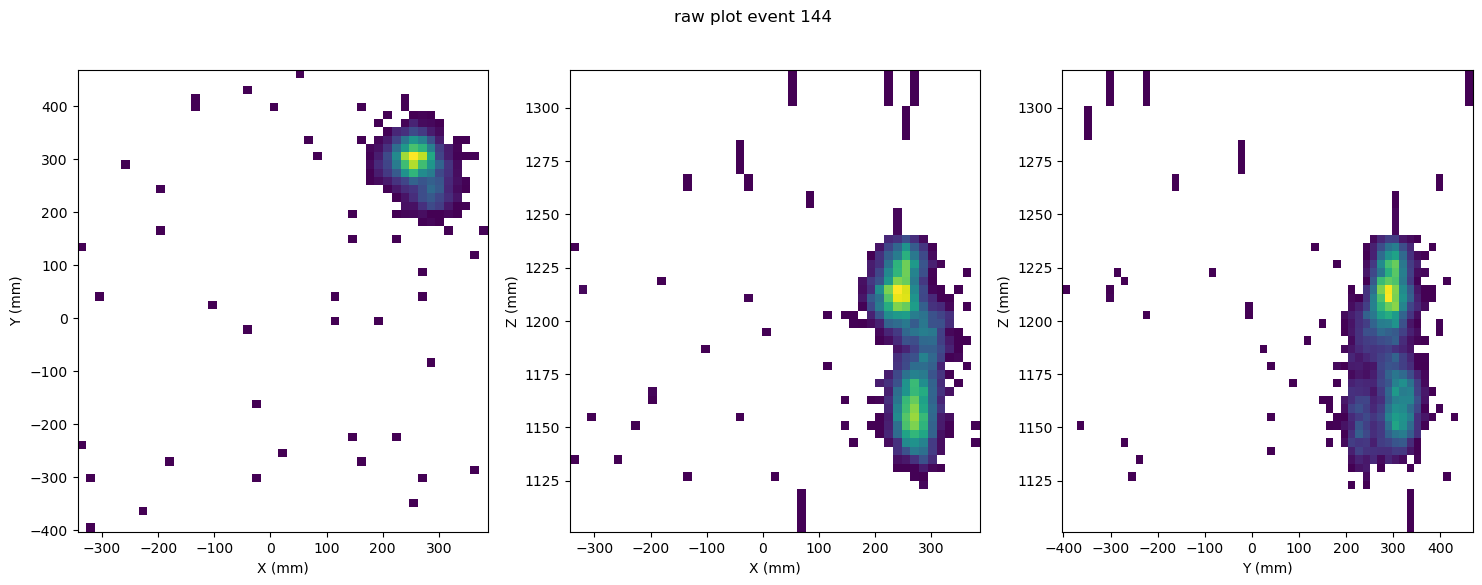

In [5]:
# sanity check
N = 6 
EOI = data[data.event == data.event.unique()[N]]
display(EOI)
raw_plotter(EOI, EOI.event.unique()[0])

In [39]:
# apply standard prescription beersheba
# Parameters involved in beersheba city and the deconvolution.
nhits = 3
deconv_params = dict(
  q_cut            = 5, #5 for 6mm  - 5 for 6mm
  drop_dist        = [16, 16, 4],
  #psf_fname        = f'/Users/halmamol/NEXT/PSF_FLEX100_mask{dist}_lowQE.h5',     
  psf_fname        = psf_path,     
  e_cut            = 1e-6, #15 for 6mm  - 15 for 6mm
  n_iterations     = 150, #150 for 6mm  - 150 for 6mm
  iteration_tol    =  1e-10,
  sample_width     = [15.55, 15.55],
  bin_size         = [ 2,  2],
  diffusion        = (1., 1.),
  n_dim            = 2,
  deconv_mode      = DeconvolutionMode.joint,
  cut_type         = CutType.abs,
  energy_type      = HitEnergy.Ec,
  satellite_params = dict(satellite_start_iter = 20, satellite_max_size = 4, e_cut = 1e-6))#,

deconv_params_   = {k : v for k, v in deconv_params.items() if k not in ['q_cut', 'drop_dist']}

# Couple of functions used in beersheba.

cut_sensors       = cut_over_Q   (deconv_params['q_cut'    ], ['E', 'Ec'])
drop_sensors      = drop_isolated(deconv_params['drop_dist'], ['E', 'Ec'], nhits)


#deconvolve = deconvolve_signal(DataSiPM(detector_db, run_number))

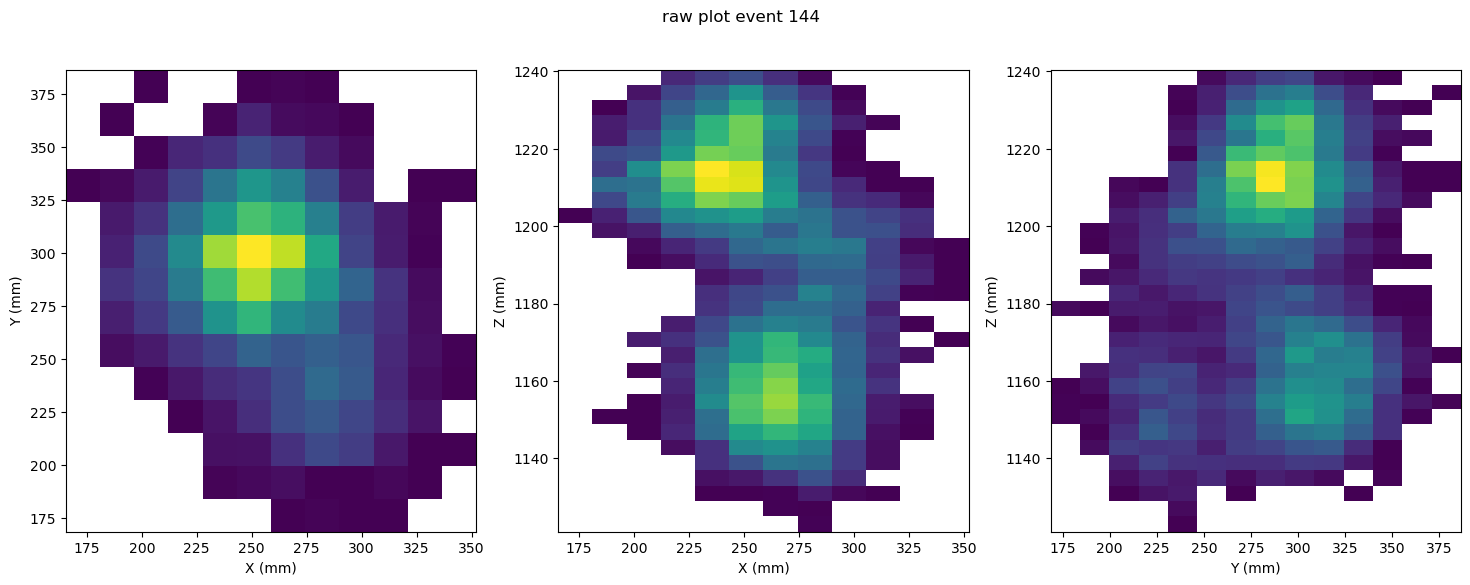

In [40]:
EOI_cut = cut_sensors(EOI)
EOI_drop = drop_sensors(EOI_cut)

raw_plotter(EOI_drop, EOI_drop.event.unique()[0])

In [41]:
# create beersheba object
detector_db = '/gluster/data/next/software/IC_john/IC/invisible_cities/database/localdb.NEXT100DB.sqlite3'
run_number = 0 
deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)

OSError: ``/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/PSF_15539_z200_xy2.0_130125.psf`` does not exist

In [ ]:
EOI_deco = deconvolver(EOI_drop)

In [ ]:
display(EOI_deco)

,event,npeak,X,Y,Z,E,Xpeak,Ypeak
0,144,33,282.875,245.575,1121.078625,5.725079e-08,124.29169,140.12136
1,144,33,282.875,247.575,1121.078625,4.516545e-08,124.29169,140.12136
2,144,33,284.875,241.575,1121.078625,8.565461e-08,124.29169,140.12136
3,144,33,284.875,243.575,1121.078625,8.808171e-07,124.29169,140.12136
4,144,33,284.875,245.575,1121.078625,2.529565e-06,124.29169,140.12136
...,...,...,...,...,...,...,...,...
19297,144,33,248.875,309.575,1240.416375,2.164095e-06,124.29169,140.12136
19298,144,33,248.875,311.575,1240.416375,3.866317e-07,124.29169,140.12136
19299,144,33,250.875,305.575,1240.416375,3.045231e-08,124.29169,140.12136
19300,144,33,250.875,307.575,1240.416375,6.973572e-08,124.29169,140.12136


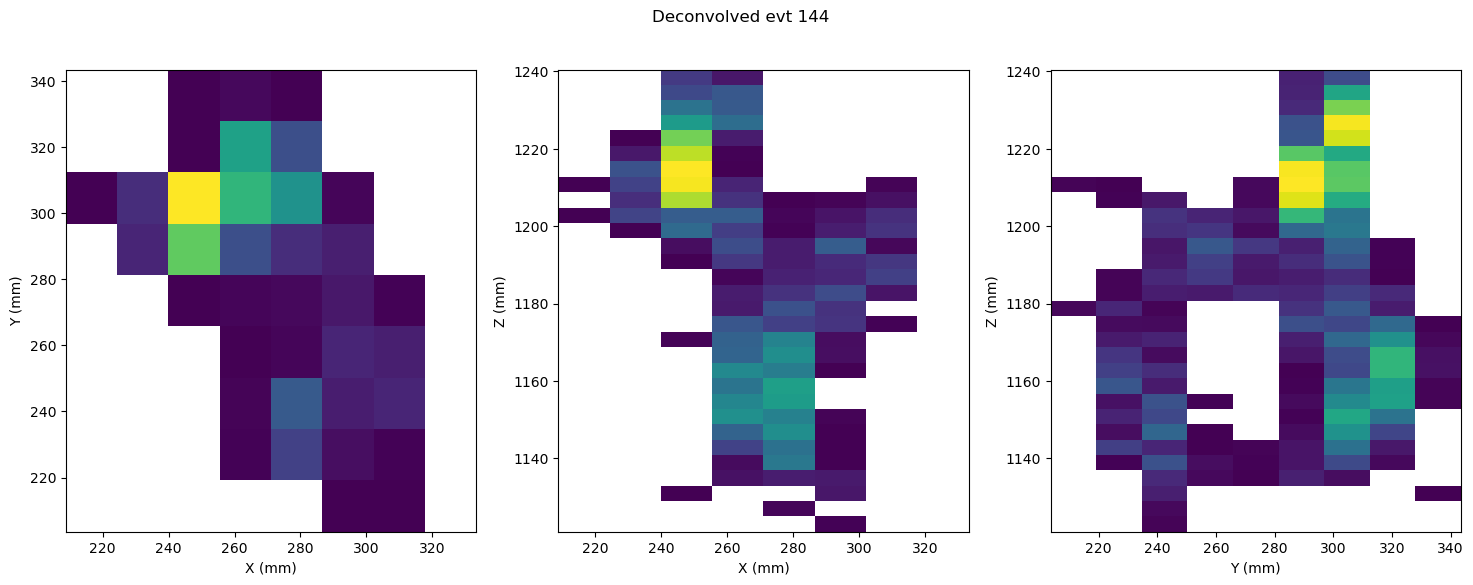

In [42]:
raw_plotter(EOI_deco, EOI_deco.event.unique()[0], param = 'E', title = f'Deconvolved evt {EOI_deco.event.unique()[0]}')

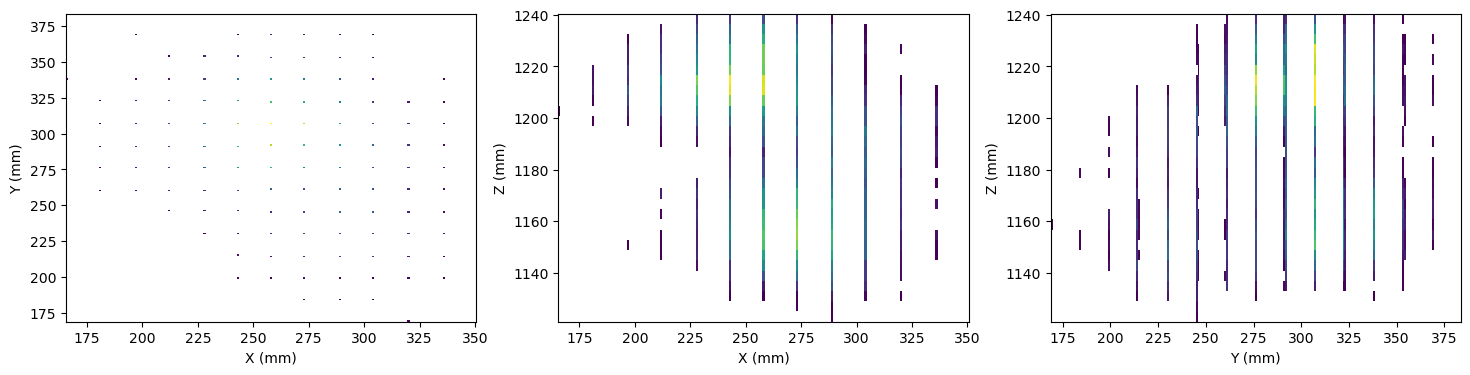

In [43]:
datatype = 'DATA'
pitch = 15.55

# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

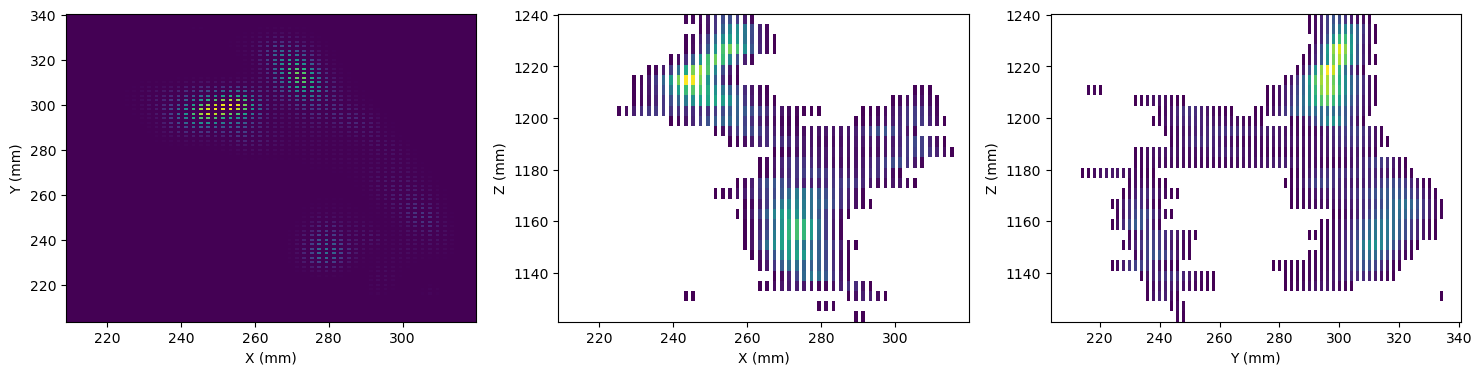

In [44]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
zz = EOI_deco.Z.unique()

axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

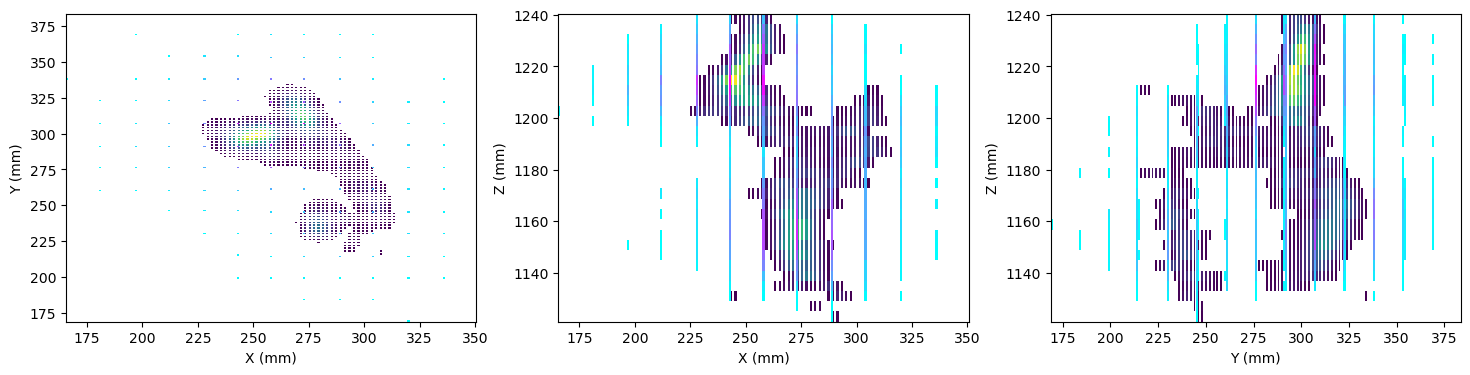

In [45]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
zz = EOI_deco.Z.unique()

axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

fig.show()

In [46]:
from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated folder {path}')

# for gif creation
png_list = []

n_iterations_max = 200 
iteration_step   = 20
for i in range(10, n_iterations_max, iteration_step):
    print(i)
    deconv_params_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max() + 2, 2)# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max() + 2, 2)# + pitch, pitch)
    zz = EOI_deco.Z.unique()

    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i} - timestamp {global_timestamp}')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated folder gif_images/103259_20260325
10


OSError: ``/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/PSF_15539_z200_xy2.0_130125.psf`` does not exist

In [48]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=2, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

# apply beershebashire here to see if it helps

In [25]:
def rebin(df, dx, dy, dz, q_type = 'Qc', e_type = 'E'):
    '''
    Docstring for rebin

    :param df: Description
    :param dx: Description
    :param dy: Description
    :param dz: Description
    '''

    x_edge = np.arange(df.X.min(), df.X.max() + dx, dx)
    y_edge = np.arange(df.Y.min(), df.Y.max() + dy, dy)
    z_edge = np.arange(df.Z.min(), df.Z.max() + dz, dz)

    # meshgrid from voxel centres
    x_centres = (x_edge[:-1] + x_edge[1:]) / 2
    y_centres = (y_edge[:-1] + y_edge[1:]) / 2
    z_centres = (z_edge[:-1] + z_edge[1:]) / 2

    xx, yy, zz = np.meshgrid(x_centres, y_centres, z_centres, indexing='ij')

    He, edges = np.histogramdd(
                            sample = np.vstack([df.X, df.Y, df.Z]).T,
                            bins   = [x_edge, y_edge, z_edge],
                            weights = df[e_type])
    #if 'Q' in df:
    #    Hq, edges = np.histogramdd(
    #                        sample = np.vstack([df.X, df.Y, df.Z]).T,
    #                        bins   = [x_edge, y_edge, z_edge],
    #                        weights = df[q_type])


    rebin_df = pd.DataFrame({
                     "event": df.event.unique()[0],
                     "npeak": df.npeak.unique()[0], # this should not just extract the first peak, very naughty
                     "X"        : xx.ravel(),
                     "Y"        : yy.ravel(),
                     "Z"        : zz.ravel(),
                     "E"        : He.ravel(),
                     "Xpeak"    : 0.0,
                     "Ypeak"    : 0.0 # we overwrite this garbage because we dont use it, naughty
                     })

    # remove empty hits (you need to do this)
    rebin_df = rebin_df[rebin_df['E'] > 0].reset_index(drop=True)

    return rebin_df

# Visual pre-beershebashire

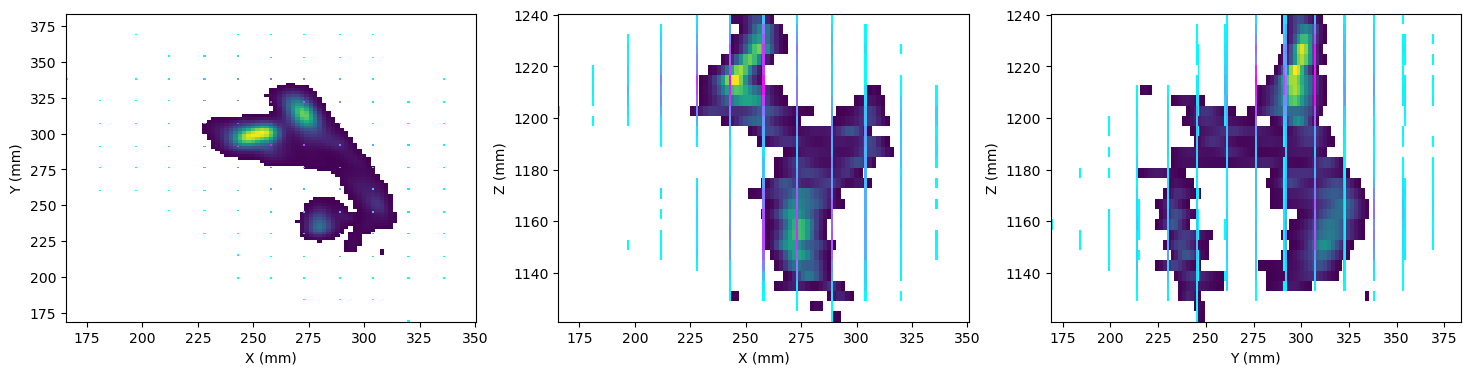

In [22]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
pitch = 2
xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max() + pitch, pitch)
yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max() + pitch, pitch)
zz = EOI_deco.Z.unique()

axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

fig.show()

In [24]:
display(EOI_deco)

,event,npeak,X,Y,Z,E,Xpeak,Ypeak
0,144,33,284.875,243.575,1121.078625,3.020390e-07,124.29169,140.12136
1,144,33,284.875,245.575,1121.078625,1.145006e-06,124.29169,140.12136
2,144,33,284.875,247.575,1121.078625,8.338132e-07,124.29169,140.12136
3,144,33,284.875,249.575,1121.078625,1.179749e-07,124.29169,140.12136
4,144,33,286.875,241.575,1121.078625,3.523254e-07,124.29169,140.12136
...,...,...,...,...,...,...,...,...
16634,144,33,248.875,303.575,1240.416375,3.214660e-08,124.29169,140.12136
16635,144,33,248.875,305.575,1240.416375,4.823917e-07,124.29169,140.12136
16636,144,33,248.875,307.575,1240.416375,1.430757e-06,124.29169,140.12136
16637,144,33,248.875,309.575,1240.416375,8.191538e-07,124.29169,140.12136


In [36]:
# rebin, then drop
rebin_d = (2, 2, 2) # mm
nhits_E = 10
drop_sensors_E      = drop_isolated(deconv_params['drop_dist'], ['E'], nhits_E)

beershebashire_data = []
for i, df in EOI_deco.groupby('event'):
    print(f'rebinning with {rebin_d[0]}, {rebin_d[1]}, {rebin_d[2]}')
    rebinned_df = rebin(df, rebin_d[0], rebin_d[1], rebin_d[2])
    print(f'rebinned from {df.shape} to {rebinned_df.shape}')
    dropped_df = drop_sensors_E(rebinned_df.copy())
    beershebashire_data.append(dropped_df)

beershebashire_data = pd.concat(beershebashire_data)

rebinning with 2, 2, 2
rebinned from (16639, 8) to (16616, 8)


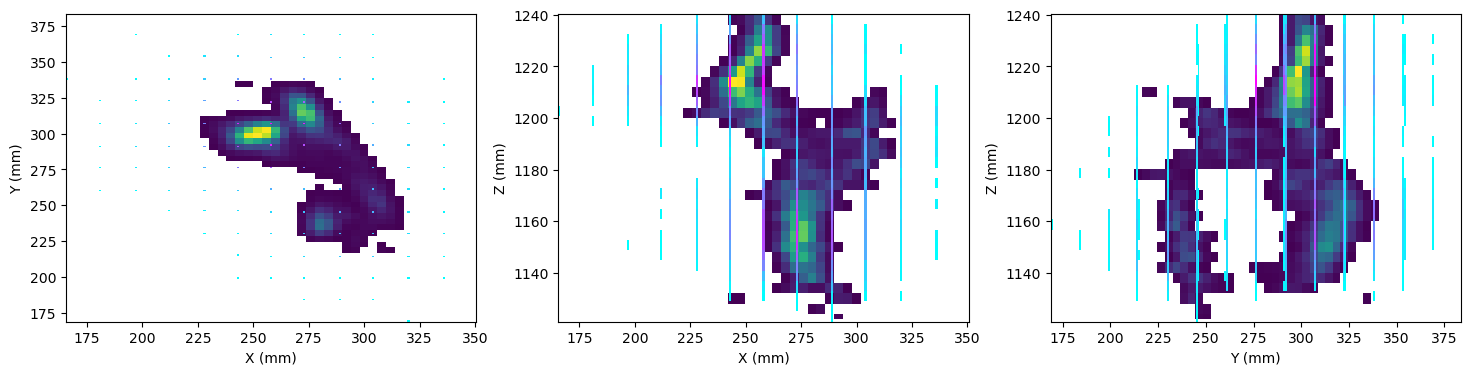

In [37]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
pitch = 4
xx = np.arange(beershebashire_data.X.min(), beershebashire_data.X.max() + pitch, pitch)
yy = np.arange(beershebashire_data.Y.min(), beershebashire_data.Y.max() + pitch, pitch)
zz = np.sort(beershebashire_data.Z.unique())

axes[0].hist2d(beershebashire_data.X, beershebashire_data.Y, bins=[xx, yy], weights=beershebashire_data.E, cmin = 0.0001);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(beershebashire_data.X, beershebashire_data.Z, bins=[xx, zz], weights=beershebashire_data.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(beershebashire_data.Y, beershebashire_data.Z, bins=[yy, zz], weights=beershebashire_data.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

fig.show()